In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sc
from scipy.optimize import curve_fit

In [2]:
def ramsey_fit(t, A, f, d, p, c):

    return A * np.exp(-t/d) * np.sin(2*np.pi*f*t + p) + c

def normalize(y, A, c):
    
    y_n = -(y - c)/np.abs(A)
    
    return y_n

plt.rc('pgf', texsystem='pdflatex')
plt.rcParams.update({
    "pgf.texsystem": "pdflatex",
    "font.family": "serif",
#     "font.serif": ["CMU serif"],                    # use latex default serif font
    'pgf.rcfonts': False,
    'figure.figsize': [6.5,4.5],
    'font.size': 14,
    # 'lines.linewidth' : 1.5,
    'axes.linewidth' : 1.1,
    'xtick.major.size' : 5,
    'xtick.minor.size' : 3,
    'ytick.major.size' : 5,
    'ytick.minor.size' : 3
})
plt.rc('axes', unicode_minus=False)

In [75]:
path = r"D:/Experiments/\2024-07-13 Ringv1-INDIQTa08,13-6Qubits-BetterShielding"
path = path + r"/Dev_TimeDomain_Conditional-Ramsey-MultiQubit/24-10-01"
det =2.5
q_no_t = 6
q_no_c_list = [1, 3, 5]
n_c_qubits = len(q_no_c_list)
perms_c_list = [np.binary_repr(i, width=n_c_qubits) for i in np.arange(2**n_c_qubits)]
n_c_perms = len(perms_c_list)

In [76]:
data = np.genfromtxt(path + f"/Dev_TimeDomain_Conditional-Ramsey-MultiQubit-CQ{q_no_c_list}TQ{q_no_t}_Target_Q{q_no_t}-21-54-36.csv",delimiter=',')
data = np.transpose(data)
n_perm = (data.shape[0] - 1)//2

In [77]:
t_list_us = data[0]
for i in range(n_perm):
    vars()[f"It_{perms_c_list[i]}"] =  data[2*i+1]


for i, perms_c_i in enumerate(perms_c_list):
    # print(perms_c_i)
    if not i or i:
        vars()[f"pars_{perms_c_i}"], vars()[f"cov_{perms_c_i}"] = curve_fit(f=ramsey_fit, xdata=t_list_us,
                                                                        ydata=eval(f"It_{perms_c_i}"),
                                                                        p0=[1e-3, det, 1, 0, -1e-4],
                                                                        bounds=(-np.inf, np.inf), maxfev=2000)
        A, c = vars()[f"pars_{perms_c_i}"][0], vars()[f"pars_{perms_c_i}"][-1]

    vars()[f"It_{perms_c_list[i]}"] = normalize(eval(f"It_{perms_c_i}"), A, c)
    vars()[f"pars_{perms_c_i}"], vars()[f"cov_{perms_c_i}"] = curve_fit(f=ramsey_fit, xdata=t_list_us,
                                                                    ydata=eval(f"It_{perms_c_i}"),
                                                                    p0=[1, det, 1, 0, -1e-4],
                                                                    bounds=(-np.inf, np.inf), maxfev=2000)

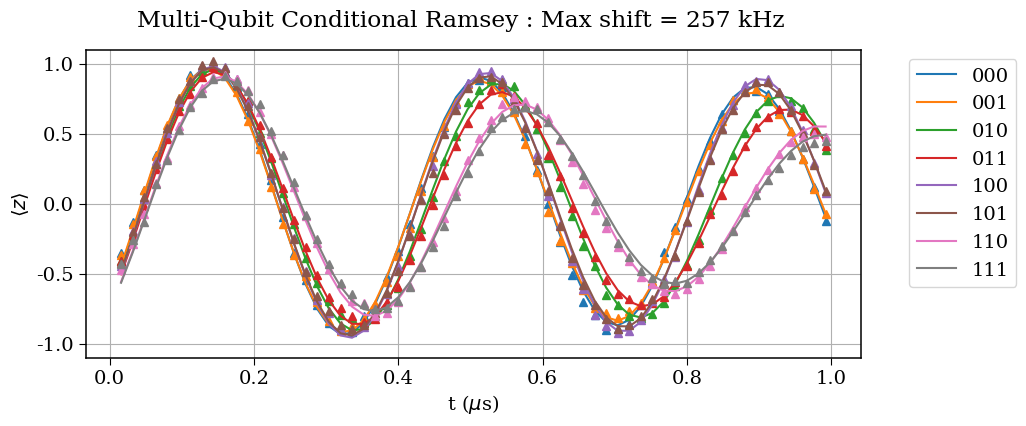

In [ ]:
det_perms_list = []
verbose = False
plt.figure(figsize=(10,4))
# plt.suptitle(f"Conditional Ramsey | Controls Q{q_no_c_list} Target Q{q_no_t}")
for i in range(n_c_perms):

    
    # Detuning in kHz
    vars()[f"det_{perms_c_list[i]}"] = 1e3 * np.abs(np.round(np.abs(eval(f"pars_000")[1]) -
                                                       np.abs(eval(f"pars_{perms_c_list[i]}")[1]), 4))
    det_perms_list.append(eval(f"det_{perms_c_list[i]}"))

    plt.plot(t_list_us, eval(f"It_{perms_c_list[i]}"), "^", color=f"C{i}")
    plt.plot(t_list_us, ramsey_fit(t_list_us, *eval(f"pars_{perms_c_list[i]}")),
             label=f"{perms_c_list[i]}", color=f"C{i}")
    if verbose:
        print(f"Ramsey frequency {perms_c_list[i]} = {eval(f'pars_{perms_c_list[i]}')[1]} MHz")
        print(f"Ramsey time {perms_c_list[i]} = {eval(f'pars_{perms_c_list[i]}')[2]} us")
        print(f"Detuning = {eval(f'det_{perms_c_list[i]}')} kHz")

plt.suptitle(f"Multi-Qubit Conditional Ramsey : Max shift = {np.max(det_perms_list):.0f} kHz")
plt.xlabel('t ($\mu$s)')
plt.ylabel(r"$\langle z \rangle$")
plt.ylim((-1.1,1.1))
# plt.title(f"Max shift = {np.max(det_perms_list)} kHz")
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.grid()
plt.show()


In [79]:
det_list_fin = np.array(det_perms_list)
det_list_fin = det_list_fin - np.mean(det_list_fin)
det_list_fin

array([-101.05,  -93.45,   12.55,   28.15,  -74.05,  -69.45,  141.15,
        156.15])

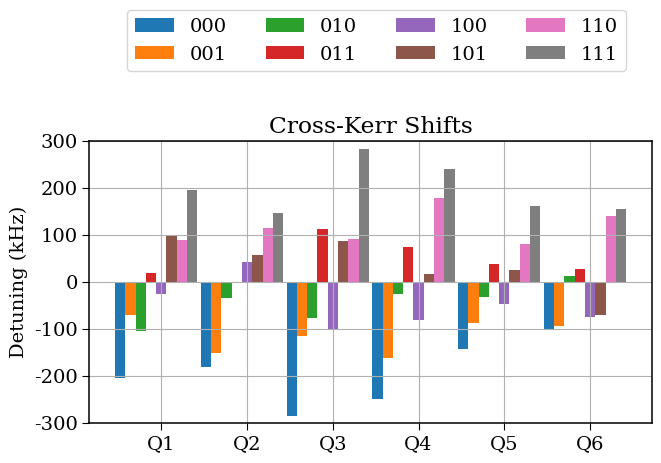

In [95]:
Q1_data = [-204.225,  -69.125, -104.525,   18.875,  -24.325,   98.375,
         89.375,  195.575]
Q2_data = [-1.80425e+02, -1.51025e+02, -3.26250e+01,  7.50000e-02,
        4.30750e+01,  5.74750e+01,  1.15675e+02,  1.47775e+02]
Q3_data = [-285.4625, -115.2625,  -76.1625,  113.0375, -100.1625,   88.5375,
         92.0375,  283.4375]
Q4_data = [-248.8875, -160.5875,  -24.4875,   74.1125,  -79.5875,   18.3125,
        180.0125,  241.1125]
Q5_data = [-142.8125,  -86.7125,  -31.8125,   39.4875,  -46.8125,   25.6875,
         80.5875,  162.3875]
Q6_data = [-101.05,  -93.45,   12.55,   28.15,  -74.05,  -69.45,  141.15,
        156.15]

qubits = ("Q1", "Q2", "Q3", "Q4", "Q5", "Q6")
cross_kerr_data = {}

for i, perm in enumerate(perms_c_list):

    data = [Q1_data[i], Q2_data[i], Q3_data[i], Q4_data[i], Q5_data[i], Q6_data[i]]
    cross_kerr_data[perm] = data 

x = np.arange(len(qubits))  # the label locations
width = 0.12  # the width of the bars
multiplier = -3

fig, ax = plt.subplots(layout='constrained')

for attribute, measurement in cross_kerr_data.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    # ax.bar_label(rects, padding=3)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Detuning (kHz)')
ax.set_title('Cross-Kerr Shifts')
ax.set_xticks(x + width, qubits)
ax.legend(bbox_to_anchor=(0.05, 1.5), loc='upper left', ncols=4)
ax.set_ylim(-300, 300)
plt.grid()
plt.savefig(fr"D:\PF\Jay\Manuscript Images\CrossKerrShifts_AllQubits_v2.pdf", dpi=900, bbox_inches = 'tight')

In [50]:
cross_kerr_data.items()

dict_items([('000', [-204.225, -204.225, -204.225, -204.225, -204.225, -204.225]), ('001', [-69.125, -69.125, -69.125, -69.125, -69.125, -69.125]), ('010', [-104.525, -104.525, -104.525, -104.525, -104.525, -104.525]), ('011', [18.875, 18.875, 18.875, 18.875, 18.875, 18.875]), ('100', [-24.325, -24.325, -24.325, -24.325, -24.325, -24.325]), ('101', [98.375, 98.375, 98.375, 98.375, 98.375, 98.375]), ('110', [89.375, 89.375, 89.375, 89.375, 89.375, 89.375]), ('111', [195.575, 195.575, 195.575, 195.575, 195.575, 195.575])])

In [55]:
def get_t_I(data):
    
    x_list, I0_list, I1_list = [], [], []
    
    for d in data:
        
        x_list.append(d[0])
        I0_list.append(d[1])
        I1_list.append(d[3])
        
    return np.array(x_list), np.array(I0_list) ,np.array(I1_list)

def ramsey_fit(t, A, f, d, p, c):

    return A * np.exp(-t/d) * np.sin(2*np.pi*f*t + p) + c


def normalize(y, A, c):
    
    y_n = (y - c)/np.abs(A)
    
    return y_n

In [80]:
def get_plot(data):
    
    t_list_us, I0, I1 = get_t_I(data)
    
    pars0, cov0 = sc.optimize.curve_fit(f=ramsey_fit, xdata=t_list_us, ydata=I0,
                        p0=[1e-3, det,1,0, -1e-4], bounds=(-np.inf, np.inf), maxfev=2000)
    pars1, cov1 = sc.optimize.curve_fit(f=ramsey_fit, xdata=t_list_us, ydata=I1, 
                            p0=[1e-3, det,0.5,0, -1e-4], bounds=(-np.inf, np.inf), maxfev=2000)
    total_det =  np.abs(np.round(abs(pars0[1]) - abs(pars1[1]),4))
    
    print('#########################')
    print('### Fitted Parameters ###')
    print('#########################')
    print("Ramsey frequency control 0 = {0} MHz".format(pars0[1]))
    print("Ramsey time control 0 = {0} us".format(pars0[2]))
    print("Ramsey frequency control 1 = {0} MHz".format(pars1[1]))
    print("Ramsey time control 1 = {0} us".format(pars1[2]))
    print("Total detuning = {0} kHz".format(1e3*total_det))
    print("ZZ error = {0} MHz".format(0.5*total_det))
    
    I0 = normalize(I0, pars0[0], pars0[-1])
    I1 = normalize(I1, pars1[0], pars1[-1])
    pars0[0], pars0[-1] = np.sign(pars0[0]), 0
    pars1[0], pars1[-1] = np.sign(pars1[0]), 0

    plt.figure()
    plt.plot(t_list_us, I0, "^", color="red")
    plt.plot(t_list_us, ramsey_fit(t_list_us,*pars0), label="Control 0", color="red")
    plt.plot(t_list_us, I1, "^", color="blue")
    plt.plot(t_list_us, ramsey_fit(t_list_us,*pars1), label="Control 1", color="blue")
    plt.xlabel('t ($\mu$s)')
    plt.ylabel(r"$\langle z \rangle$")
    plt.ylim((-1.1,1.1))
    plt.title("Conditional Ramsey; Total shift = {0} kHz".format(1e3*total_det))
    plt.legend()
    plt.grid()
    plt.show()

#########################
### Fitted Parameters ###
#########################
Ramsey frequency control 0 = 0.9265944733850608 MHz
Ramsey time control 0 = 5.087715553919372 us
Ramsey frequency control 1 = -0.7274135420033531 MHz
Ramsey time control 1 = 3.7355395847097084 us
Total detuning = 199.2 kHz
ZZ error = 0.0996 MHz


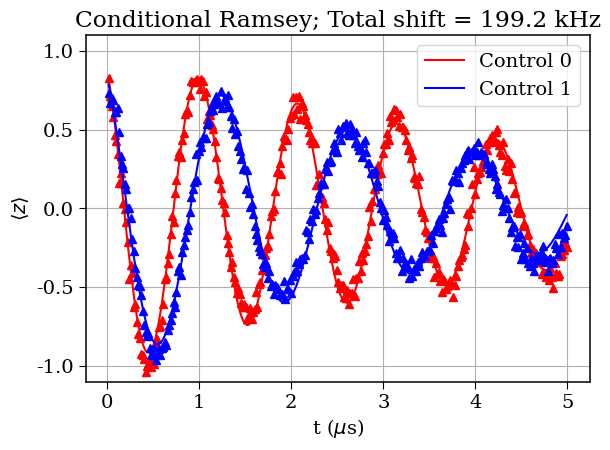

In [81]:
get_plot(data_43)

#########################
### Fitted Parameters ###
#########################
Ramsey frequency control 0 = 0.9242516918342782 MHz
Ramsey time control 0 = 5.122721248930551 us
Ramsey frequency control 1 = -0.9298025057924364 MHz
Ramsey time control 1 = 4.824770881635727 us
Total detuning = 5.6 kHz
ZZ error = 0.0028 MHz


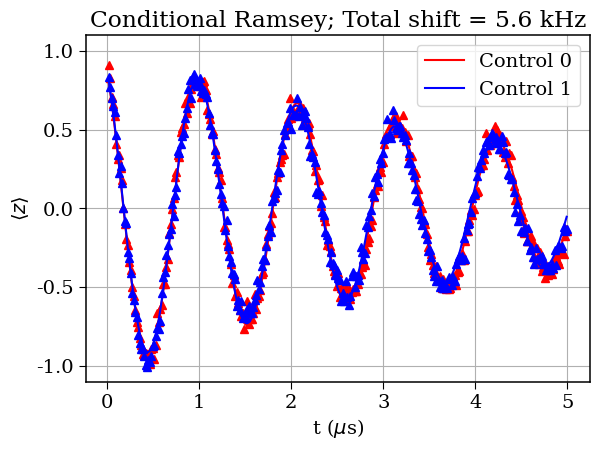

In [82]:
get_plot(data_13)